User-independent eval:  10%|█         | 1/10 [18:44<2:48:42, 1124.75s/user]

User-independent eval:  20%|██        | 2/10 [36:11<2:23:50, 1078.85s/user]

User-independent eval: 100%|██████████| 10/10 [3:03:00<00:00, 1098.06s/user] 



User-independent Accuracy: 85.30%


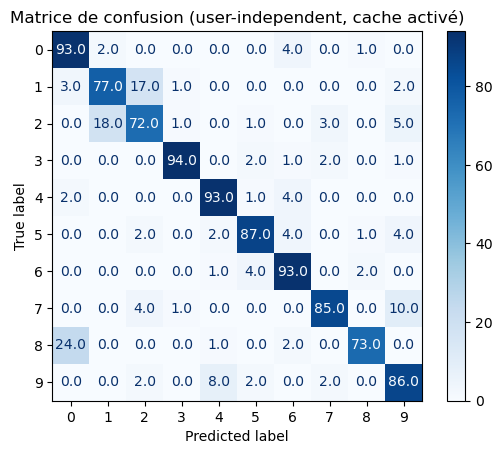

Durée totale : 183.0 minutes


In [6]:
# 0. Imports + création du dossier de cache
import os, joblib, time
import numpy as np
import pandas as pd
from collections import defaultdict
from tqdm import tqdm
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score, confusion_matrix, ConfusionMatrixDisplay
from sklearn.neighbors import KNeighborsClassifier
from tensorflow.keras.models import Model
from tensorflow.keras.layers import Input, Masking, LSTM, Bidirectional, Dropout, Dense
from tensorflow.keras.utils import to_categorical
import matplotlib.pyplot as plt

CACHE_DIR = "lstm_knn_cache_userind"
os.makedirs(CACHE_DIR, exist_ok=True)

# 1. Charger & grouper (user‐independent: on regroupe par user + gesture)
df = pd.read_csv("Standardize.csv")
df = df[df['x'] != 'x']
df[['x','y','z','time']] = df[['x','y','z','time']].astype(float)
df['gesture'] = df['gesture'].astype(int)

# sequences_user[user] = list of (gesture_id, np.array of shape (T,4))
sequences_user = defaultdict(list)
grouped = df.groupby(['user','gesture','sequence'])
for (user, gesture, _), grp in grouped:
    seq = grp.sort_values('time')[['x','y','z','time']].to_numpy()
    sequences_user[user].append((gesture, seq))

# 2. Calculer global_max (une seule fois pour toutes les séquences)
all_seqs = [seq for seqs in sequences_user.values() for _, seq in seqs]
global_max = max(seq.shape[0] for seq in all_seqs)

# 3. Fonction de prétraitement (interpolation + scaling)
def preprocess(sequences, max_len=global_max, scaler=None, fit_scaler=True):
    X, y = [], []
    for gesture_id, seq in sequences:
        ori = seq.shape[0]
        oi = np.linspace(0,1,ori)
        ti = np.linspace(0,1,max_len)
        feats = [np.interp(ti, oi, seq[:,c]) for c in range(4)]
        X.append(np.stack(feats,axis=1))
        y.append(gesture_id)
    X = np.array(X)
    if fit_scaler:
        scaler = StandardScaler()
        X = scaler.fit_transform(X.reshape(-1,4)).reshape(X.shape)
    else:
        X = scaler.transform(X.reshape(-1,4)).reshape(X.shape)
    y = to_categorical(y, num_classes=10)
    return X, y, scaler

# 4. Construction et compilation du modèle LSTM (une seule fois)
def build_lstm(input_shape=(global_max,4)):
    inp = Input(shape=input_shape)
    x = Masking(0.)(inp)
    x = LSTM(128, return_sequences=True)(x)
    x = Dropout(0.1)(x)
    x = Bidirectional(LSTM(64))(x)
    x = Dropout(0.1)(x)
    x = Dense(64, activation='relu')(x)
    emb = Dense(32, activation='relu', name="embedding")(x)
    out = Dense(10, activation='softmax')(emb)
    m = Model(inputs=inp, outputs=out)
    m.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])
    return m

model = build_lstm()  # ne sera jamais reconstruit

# 5. Leave-one-user-out (user-independent) avec cache et barre de progression
all_y_true, all_y_pred = [], []
users = sorted(sequences_user.keys())
start = time.time()

for u in tqdm(users, desc="User-independent eval", unit="user"):
    # 5.a. Préparer train/test pour utilisateur u
    train_seqs = [item for usr, seqs in sequences_user.items() if usr != u for item in seqs]
    test_seqs  = sequences_user[u]

    # 5.b. Prétraitement
    Xtr, ytr, scaler = preprocess(train_seqs, fit_scaler=True)
    Xte, yte, _      = preprocess(test_seqs,  scaler=scaler, fit_scaler=False)

    # 5.c. Définir chemins cache (poids en .weights.h5)
    wp = f"{CACHE_DIR}/lstm_weights_user{u}.weights.h5"
    sp = f"{CACHE_DIR}/scaler_user{u}.joblib"
    xp = f"{CACHE_DIR}/Xemb_user{u}.npy"
    yp = f"{CACHE_DIR}/Yemb_user{u}.npy"

    # 5.d. Charger ou entraîner + sauvegarder
    if os.path.exists(wp) and os.path.exists(sp) and os.path.exists(xp) and os.path.exists(yp):
        model.load_weights(wp)
        scaler = joblib.load(sp)
        Xtr_emb = np.load(xp)
        ytr_lab = np.load(yp)
    else:
        model.fit(Xtr, ytr, validation_split=0.1, epochs=100, batch_size=16, verbose=0)
        model.save_weights(wp)
        joblib.dump(scaler, sp)
        emb_model = Model(inputs=model.input, outputs=model.get_layer("embedding").output)
        Xtr_emb = emb_model.predict(Xtr, verbose=0)
        ytr_lab = np.argmax(ytr, axis=1)
        np.save(xp, Xtr_emb)
        np.save(yp, ytr_lab)

    # 5.e. Extraire embeddings test + k-NN
    emb_model = Model(inputs=model.input, outputs=model.get_layer("embedding").output)
    Xte_emb = emb_model.predict(Xte, verbose=0)
    knn = KNeighborsClassifier(n_neighbors=3)
    knn.fit(Xtr_emb, ytr_lab)
    y_pred = knn.predict(Xte_emb)

    all_y_true.extend(np.argmax(yte, axis=1))
    all_y_pred.extend(y_pred)

# 6. Affichage du résultat final
acc = accuracy_score(all_y_true, all_y_pred)
print(f"\nUser-independent Accuracy: {acc*100:.2f}%")
cm = confusion_matrix(all_y_true, all_y_pred, labels=range(10))
cm_pct = cm.astype(float)/cm.sum(axis=1)[:,None]*100
disp = ConfusionMatrixDisplay(confusion_matrix=cm_pct, display_labels=range(10))
disp.plot(cmap="Blues", values_format=".1f")
plt.title("Matrice de confusion (user-independent, cache activé)")
plt.show()

print(f"Durée totale : {(time.time()-start)/60:.1f} minutes")


User-independent eval:   0%|          | 0/10 [00:00<?, ?user/s]c:\Users\Skander\AppData\Local\Programs\Orange\Lib\site-packages\keras\src\saving\saving_lib.py:757: UserWarning: Skipping variable loading for optimizer 'adam', because it has 2 variables whereas the saved optimizer has 32 variables. 
  saveable.load_own_variables(weights_store.get(inner_path))
User-independent eval:  10%|█         | 1/10 [00:02<00:18,  2.05s/user]c:\Users\Skander\AppData\Local\Programs\Orange\Lib\site-packages\keras\src\saving\saving_lib.py:757: UserWarning: Skipping variable loading for optimizer 'adam', because it has 2 variables whereas the saved optimizer has 32 variables. 
  saveable.load_own_variables(weights_store.get(inner_path))
User-independent eval:  20%|██        | 2/10 [00:04<00:20,  2.55s/user]c:\Users\Skander\AppData\Local\Programs\Orange\Lib\site-packages\keras\src\saving\saving_lib.py:757: UserWarning: Skipping variable loading for optimizer 'adam', because it has 2 variables whereas the 


User-independent Accuracy: 85.30%


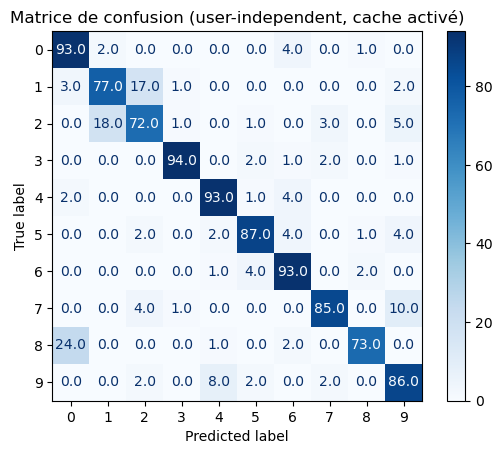

Durée totale : 0.4 minutes


In [ ]:
# 0. Imports + création du dossier de cache
import os, joblib, time
import numpy as np
import pandas as pd
from collections import defaultdict
from tqdm import tqdm
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score, confusion_matrix, ConfusionMatrixDisplay
from sklearn.neighbors import KNeighborsClassifier
from tensorflow.keras.models import Model
from tensorflow.keras.layers import Input, Masking, LSTM, Bidirectional, Dropout, Dense
from tensorflow.keras.utils import to_categorical
import matplotlib.pyplot as plt

CACHE_DIR = "lstm_knn_cache_userind"
os.makedirs(CACHE_DIR, exist_ok=True)

# 1. Charger & grouper (user‐independent: on regroupe par user + gesture)
df = pd.read_csv("Standardize.csv")
df = df[df['x'] != 'x']
df[['x','y','z','time']] = df[['x','y','z','time']].astype(float)
df['gesture'] = df['gesture'].astype(int)

# sequences_user[user] = list of (gesture_id, np.array of shape (T,4))
sequences_user = defaultdict(list)
grouped = df.groupby(['user','gesture','sequence'])
for (user, gesture, _), grp in grouped:
    seq = grp.sort_values('time')[['x','y','z','time']].to_numpy()
    sequences_user[user].append((gesture, seq))

# 2. Calculer global_max (une seule fois pour toutes les séquences)
all_seqs = [seq for seqs in sequences_user.values() for _, seq in seqs]
global_max = max(seq.shape[0] for seq in all_seqs)

# 3. Fonction de prétraitement (interpolation + scaling)
def preprocess(sequences, max_len=global_max, scaler=None, fit_scaler=True):
    X, y = [], []
    for gesture_id, seq in sequences:
        ori = seq.shape[0]
        oi = np.linspace(0,1,ori)
        ti = np.linspace(0,1,max_len)
        feats = [np.interp(ti, oi, seq[:,c]) for c in range(4)]
        X.append(np.stack(feats,axis=1))
        y.append(gesture_id)
    X = np.array(X)
    if fit_scaler:
        scaler = StandardScaler()
        X = scaler.fit_transform(X.reshape(-1,4)).reshape(X.shape)
    else:
        X = scaler.transform(X.reshape(-1,4)).reshape(X.shape)
    y = to_categorical(y, num_classes=10)
    return X, y, scaler

# 4. Construction et compilation du modèle LSTM (une seule fois)
def build_lstm(input_shape=(global_max,4)):
    inp = Input(shape=input_shape)
    x = Masking(0.)(inp)
    x = LSTM(128, return_sequences=True)(x)
    x = Dropout(0.1)(x)
    x = Bidirectional(LSTM(64))(x)
    x = Dropout(0.1)(x)
    x = Dense(64, activation='relu')(x)
    emb = Dense(32, activation='relu', name="embedding")(x)
    out = Dense(10, activation='softmax')(emb)
    m = Model(inputs=inp, outputs=out)
    m.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])
    return m

model = build_lstm()  # ne sera jamais reconstruit

# 5. Leave-one-user-out (user-independent) avec cache et barre de progression
all_y_true, all_y_pred = [], []
users = sorted(sequences_user.keys())
start = time.time()

for u in tqdm(users, desc="User-independent eval", unit="user"):
    # 5.a. Préparer train/test pour utilisateur u
    train_seqs = [item for usr, seqs in sequences_user.items() if usr != u for item in seqs]
    test_seqs  = sequences_user[u]

    # 5.b. Prétraitement
    Xtr, ytr, scaler = preprocess(train_seqs, fit_scaler=True)
    Xte, yte, _      = preprocess(test_seqs,  scaler=scaler, fit_scaler=False)

    # 5.c. Définir chemins cache (poids en .weights.h5)
    wp = f"{CACHE_DIR}/lstm_weights_user{u}.weights.h5"
    sp = f"{CACHE_DIR}/scaler_user{u}.joblib"
    xp = f"{CACHE_DIR}/Xemb_user{u}.npy"
    yp = f"{CACHE_DIR}/Yemb_user{u}.npy"

    # 5.d. Charger ou entraîner + sauvegarder
    if os.path.exists(wp) and os.path.exists(sp) and os.path.exists(xp) and os.path.exists(yp):
        model.load_weights(wp)
        scaler = joblib.load(sp)
        Xtr_emb = np.load(xp)
        ytr_lab = np.load(yp)
    else:
        model.fit(Xtr, ytr, validation_split=0.1, epochs=100, batch_size=16, verbose=0)
        model.save_weights(wp)
        joblib.dump(scaler, sp)
        emb_model = Model(inputs=model.input, outputs=model.get_layer("embedding").output)
        Xtr_emb = emb_model.predict(Xtr, verbose=0)
        ytr_lab = np.argmax(ytr, axis=1)
        np.save(xp, Xtr_emb)
        np.save(yp, ytr_lab)

    # 5.e. Extraire embeddings test + k-NN
    emb_model = Model(inputs=model.input, outputs=model.get_layer("embedding").output)
    Xte_emb = emb_model.predict(Xte, verbose=0)
    knn = KNeighborsClassifier(n_neighbors=3)
    knn.fit(Xtr_emb, ytr_lab)
    y_pred = knn.predict(Xte_emb)

    all_y_true.extend(np.argmax(yte, axis=1))
    all_y_pred.extend(y_pred)

# 6. Affichage du résultat final
acc = accuracy_score(all_y_true, all_y_pred)
print(f"\nUser-independent Accuracy: {acc*100:.2f}%")
cm = confusion_matrix(all_y_true, all_y_pred, labels=range(10))
cm_pct = cm.astype(float)/cm.sum(axis=1)[:,None]*100
disp = ConfusionMatrixDisplay(confusion_matrix=cm_pct, display_labels=range(10))
disp.plot(cmap="Blues", values_format=".1f")
plt.title("Matrice de confusion (user-independent, cache activé)")
plt.show()

print(f"Durée totale : {(time.time()-start)/60:.1f} minutes")


In [5]:
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Input
import numpy as np
import os

# 1. Créer un modèle bidon
model = Sequential([
    Input(shape=(10,)),
    Dense(8, activation='relu'),
    Dense(1, activation='sigmoid')
])
model.compile(optimizer='adam', loss='binary_crossentropy')

# 2. Générer des données factices
X = np.random.rand(100, 10)
y = np.random.randint(0, 2, size=(100,))

# 3. Entraîner brièvement
model.fit(X, y, epochs=1, batch_size=10, verbose=0)

# 4. Essayer de sauvegarder avec une mauvaise extension
path = 'dummy_model.keras'
print(f"Tentative de save_weights('{path}') :")
try:
    model.save_weights(path)
    print("Aucun problème rencontré.")
except ValueError as e:
    print("Erreur capturée :", e)
    # 5. Correction automatique de l'extension
    corrected_path = path if path.endswith(".weights.h5") else f"{path}.weights.h5"
    model.save_weights(corrected_path)
    print("Poids sauvegardés dans :", corrected_path)

# 6. Vérifier que le fichier existe
files = [f for f in os.listdir('.') if f.startswith('dummy_model')]
print("Fichiers générés :", files)


Tentative de save_weights('dummy_model.keras') :
Erreur capturée : The filename must end in `.weights.h5`. Received: filepath=dummy_model.keras
Poids sauvegardés dans : dummy_model.keras.weights.h5
Fichiers générés : ['dummy_model.keras.weights.h5']
